# CardioScope-XAI — Feature-Level Fusion
Concatenates LSTM temporal embeddings with XGBoost clinical features and trains a unified risk classifier that outputs Low / Medium / High risk tiers.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_and_clean
from src.feature_engineering import build_feature_matrix
from src.temporal_data import build_temporal_dataset, load_temporal_data
from src.lstm_model import load_encoder, extract_embeddings
from src.fusion import build_fused_matrix, train, predict_risk, RISK_LABELS, RISK_COLORS

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load Clinical Features

In [2]:
df = load_and_clean('../data/raw/heart_disease_uci.csv')
X_clinical, scaler = build_feature_matrix(df, fit_scaler=False,
                                           scaler=__import__('joblib').load('../models/scaler.pkl'))
y = df['target'].values

print(f'Clinical feature matrix: {X_clinical.shape}')

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137
[feature_engineering] Final feature matrix: 25 features, 297 samples.
Clinical feature matrix: (297, 25)


## 2. Load LSTM Temporal Embeddings

In [3]:
# Option A: load pre-saved embeddings (if notebook 04 was already run)
try:
    lstm_embeddings = np.load('../data/temporal/lstm_embeddings.npy')
    print(f'Loaded pre-saved embeddings: {lstm_embeddings.shape}')

# Option B: re-generate from encoder model
except FileNotFoundError:
    print('Embeddings not found — generating from encoder model...')
    sequences, labels = load_temporal_data()
    encoder = load_encoder()
    lstm_embeddings = extract_embeddings(encoder, sequences)
    np.save('../data/temporal/lstm_embeddings.npy', lstm_embeddings)
    print(f'Generated embeddings: {lstm_embeddings.shape}')

Loaded pre-saved embeddings: (297, 16)


## 3. Build Fused Feature Matrix

In [4]:
X_fused = build_fused_matrix(X_clinical, lstm_embeddings)
print(f'Fused matrix shape: {X_fused.shape}')
print(f'  Clinical features : {X_clinical.shape[1]}')
print(f'  Temporal embedding: {lstm_embeddings.shape[1]}')
print(f'  Total             : {X_fused.shape[1]}')

[fusion] Fused matrix shape: (297, 41)  (clinical=25 + temporal=16)
Fused matrix shape: (297, 41)
  Clinical features : 25
  Temporal embedding: 16
  Total             : 41


## 4. Train Fusion Classifier

In [5]:
fusion_model, metrics = train(X_fused, y, log_mlflow=True)

print('\n── Fusion Model Metrics ──')
for k, v in metrics.items():
    print(f'  {k:20s}: {v}')

2026/05/22 22:01:01 INFO mlflow.tracking.fluent: Experiment with name 'CardioScope-XAI / Fusion' does not exist. Creating a new experiment.


[fusion] Model saved → C:\Users\admin\Desktop\CardioScope-XAI\CardioScope-XAI\models\fusion_model.pkl

── Fusion Model Metrics ──
              precision    recall  f1-score   support

  No Disease       0.88      0.91      0.89        32
     Disease       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60


── Fusion Model Metrics ──
  accuracy            : 0.8833
  recall              : 0.8571
  precision           : 0.8889
  f1                  : 0.8727
  auc_roc             : 0.9609
  cv_recall_mean      : 0.8026
  cv_recall_std       : 0.0828


## 5. Risk Tier Distribution

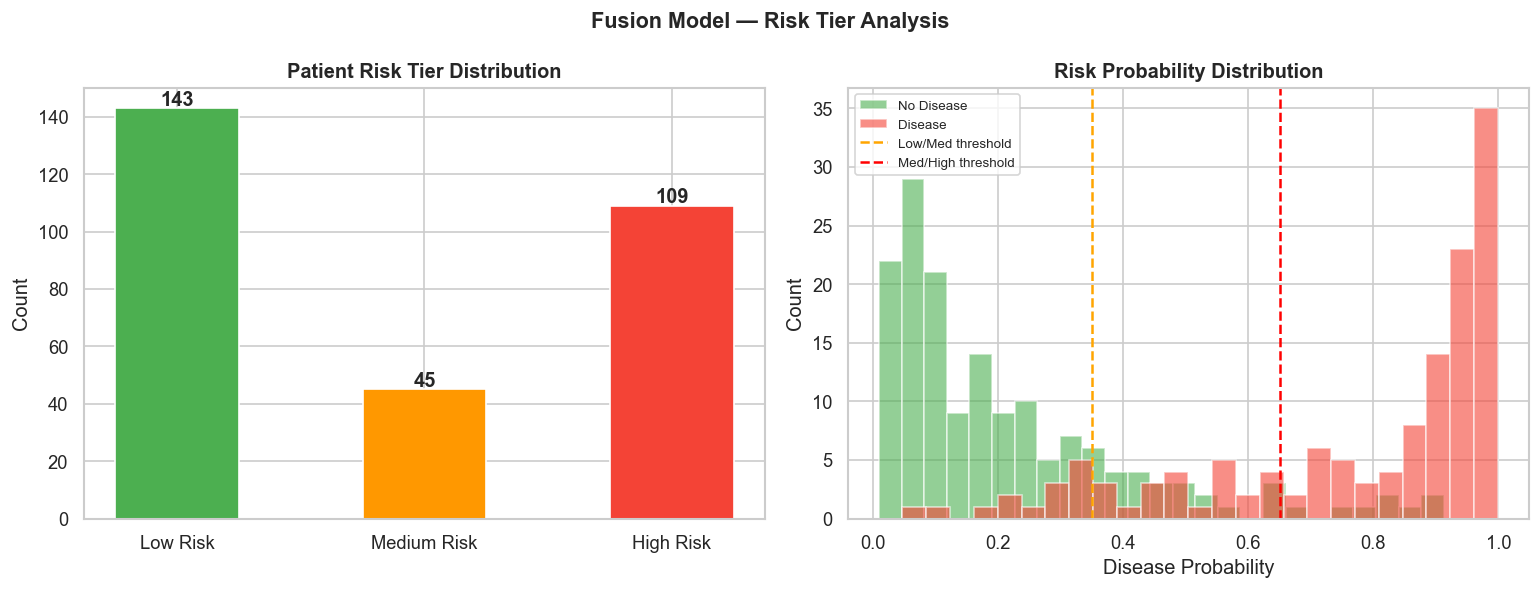

In [6]:
probabilities, risk_tiers = predict_risk(fusion_model, X_fused)

tier_counts = pd.Series(risk_tiers).value_counts().sort_index()
tier_labels = [RISK_LABELS[i] for i in tier_counts.index]
tier_colors = [RISK_COLORS[i] for i in tier_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(tier_labels, tier_counts.values, color=tier_colors, edgecolor='white', width=0.5)
axes[0].set_title('Patient Risk Tier Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', fontweight='bold')

# Probability histogram
axes[1].hist(probabilities[y==0], bins=25, alpha=0.6, color='#4CAF50', label='No Disease', edgecolor='white')
axes[1].hist(probabilities[y==1], bins=25, alpha=0.6, color='#F44336', label='Disease',    edgecolor='white')
axes[1].axvline(0.35, color='orange', linestyle='--', lw=1.5, label='Low/Med threshold')
axes[1].axvline(0.65, color='red',    linestyle='--', lw=1.5, label='Med/High threshold')
axes[1].set_title('Risk Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Disease Probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.suptitle('Fusion Model — Risk Tier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Compare: XGBoost-Only vs Fusion

                Model  Recall     F1  AUC-ROC
         XGBoost Only  0.7857 0.8302   0.9342
LSTM + XGBoost Fusion  0.8571 0.8727   0.9609


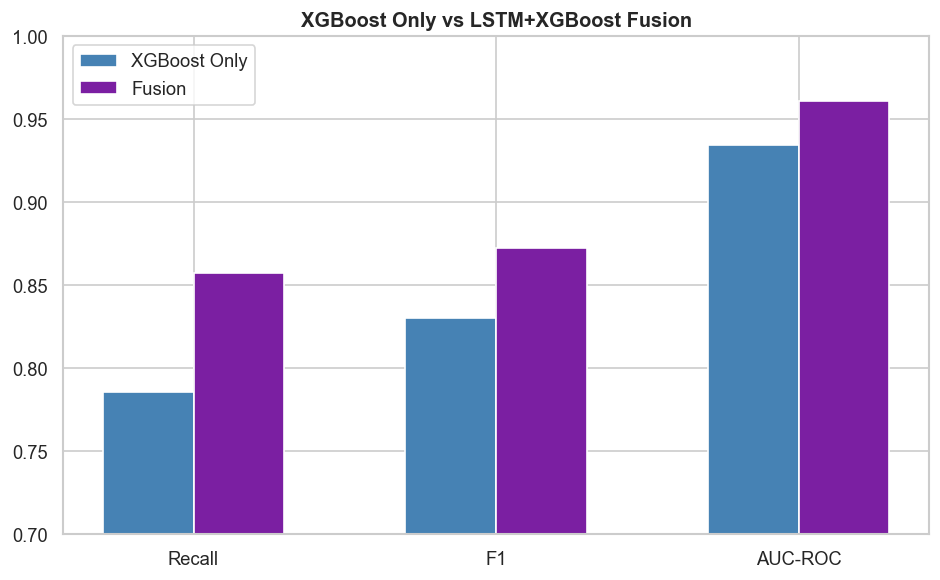

In [7]:
from src.xgboost_model import load_model as load_xgb, evaluate as xgb_evaluate
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clinical, y, test_size=0.2, random_state=42, stratify=y
)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fused, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = load_xgb('../models/xgboost_model.pkl')

from sklearn.metrics import recall_score, f1_score, roc_auc_score

xgb_pred   = xgb_model.predict(X_test_c)
xgb_proba  = xgb_model.predict_proba(X_test_c)[:, 1]
fuse_proba = fusion_model.predict_proba(X_test_f)[:, 1]
fuse_pred  = fusion_model.predict(X_test_f)

comparison = pd.DataFrame({
    'Model':     ['XGBoost Only', 'LSTM + XGBoost Fusion'],
    'Recall':    [recall_score(y_test_c, xgb_pred),  recall_score(y_test_f, fuse_pred)],
    'F1':        [f1_score(y_test_c, xgb_pred),      f1_score(y_test_f, fuse_pred)],
    'AUC-ROC':   [roc_auc_score(y_test_c, xgb_proba), roc_auc_score(y_test_f, fuse_proba)],
}).round(4)

print(comparison.to_string(index=False))

# Plot comparison
x = np.arange(3)
width = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, comparison[['Recall','F1','AUC-ROC']].iloc[0], width,
       label='XGBoost Only', color='steelblue', edgecolor='white')
ax.bar(x + width/2, comparison[['Recall','F1','AUC-ROC']].iloc[1], width,
       label='Fusion', color='#7B1FA2', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Recall', 'F1', 'AUC-ROC'])
ax.set_ylim(0.7, 1.0)
ax.set_title('XGBoost Only vs LSTM+XGBoost Fusion', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sample Patient Risk Predictions

In [8]:
sample_indices = [0, 5, 10, 15, 20]
sample_fused   = X_fused[sample_indices]
sample_probs, sample_tiers = predict_risk(fusion_model, sample_fused)

results = pd.DataFrame({
    'Patient':     sample_indices,
    'Actual':      ['Disease' if y[i]==1 else 'No Disease' for i in sample_indices],
    'Probability': sample_probs.round(3),
    'Risk Tier':   [RISK_LABELS[t] for t in sample_tiers],
})
print(results.to_string(index=False))

 Patient     Actual  Probability   Risk Tier
       0 No Disease        0.297    Low Risk
       5 No Disease        0.070    Low Risk
      10 No Disease        0.415 Medium Risk
      15 No Disease        0.072    Low Risk
      20 No Disease        0.466 Medium Risk


## Summary

| Item | Detail |
|---|---|
| Clinical features | Engineered + encoded UCI features |
| Temporal embedding | 16-dim LSTM latent vector |
| Fused dimension | Clinical + 16 |
| Fusion head | LogisticRegression (class_weight=balanced) |
| Risk tiers | Low (<0.35) / Medium (0.35–0.65) / High (>0.65) |
| Saved | `models/fusion_model.pkl` |